### Assignment No.5

In [3]:
#Task1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("Cardiotocographic.csv")
print(df.shape)       # (2126, 14)
df.info()
df.head()

for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mean(), inplace=True)

df['NSP'] = df['NSP'].round().astype(int)
df['NSP_Label'] = df['NSP'].map({1: 'Normal', 2: 'Suspect', 3: 'Pathological'})

(2126, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [4]:
#Task2
numeric_cols = ['LB','AC','FM','UC','DL','DS','DP','ASTV','MSTV','ALTV','MLTV']
stats = df[numeric_cols].agg(['mean','median','std']).T
stats['IQR'] = df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
print(stats.round(4))


          mean    median      std      IQR
LB    133.3436  133.0000  11.2143  14.0000
AC      0.0032    0.0017   0.0044   0.0056
FM      0.0099    0.0000   0.0675   0.0026
UC      0.0044    0.0045   0.0033   0.0047
DL      0.0019    0.0000   0.0033   0.0033
DS      0.0000    0.0000   0.0001   0.0000
DP      0.0002    0.0000   0.0008   0.0000
ASTV   46.9960   49.0000  18.8140  29.0000
MSTV    1.3644    1.2000   1.1736   1.0000
ALTV   10.2860    0.0000  21.2050  11.0000
MLTV    8.2849    7.5000   7.7344   6.2000


Key Findings: ALTV has a median of 0 but a mean of 10.29 — extreme positive skew indicating most patients have no long-term variability but a few have very high values .

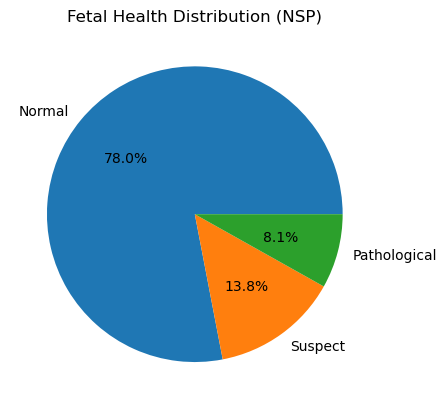

In [5]:
#Task3 
#Pie chart
nsp_counts = df['NSP_Label'].value_counts()
plt.pie(nsp_counts, labels=nsp_counts.index, autopct='%1.1f%%')
plt.title("Fetal Health Distribution (NSP)")
plt.show()


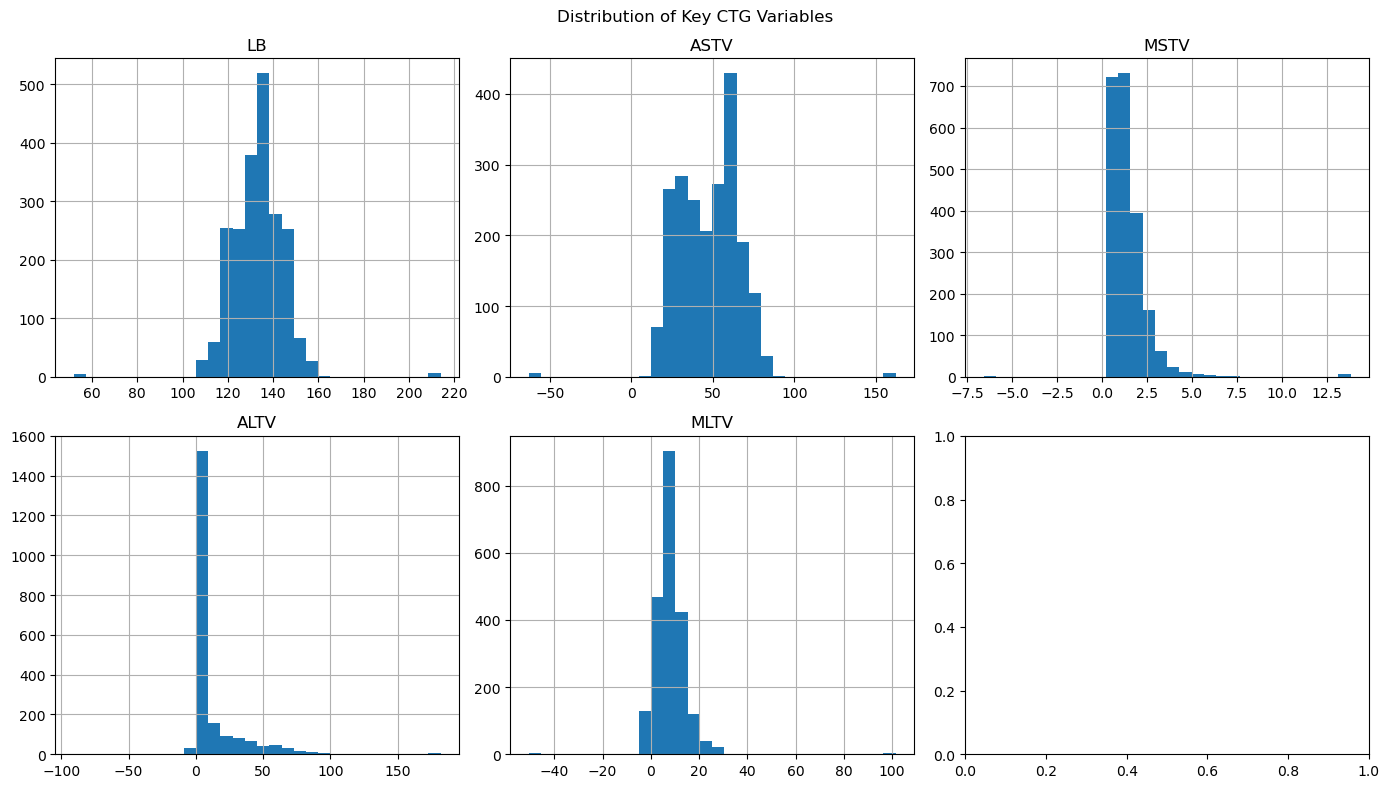

In [6]:
#Histogram
fig, axes = plt.subplots(2, 3, figsize=(14,8))
for ax, col in zip(axes.flatten(), ['LB','ASTV','MSTV','ALTV','MLTV']):
    df[col].hist(ax=ax, bins=30)
    ax.set_title(col)
plt.suptitle("Distribution of Key CTG Variables")
plt.tight_layout()
plt.show()

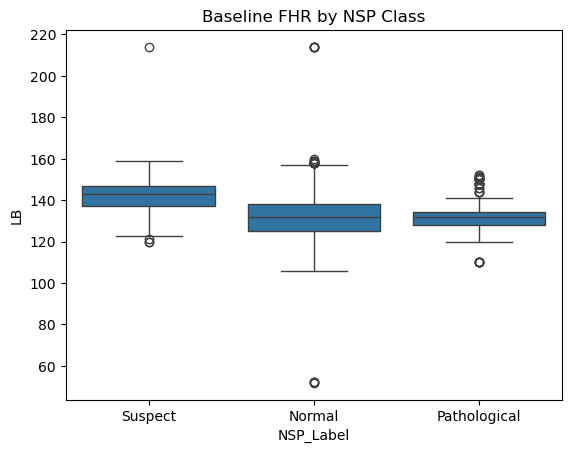

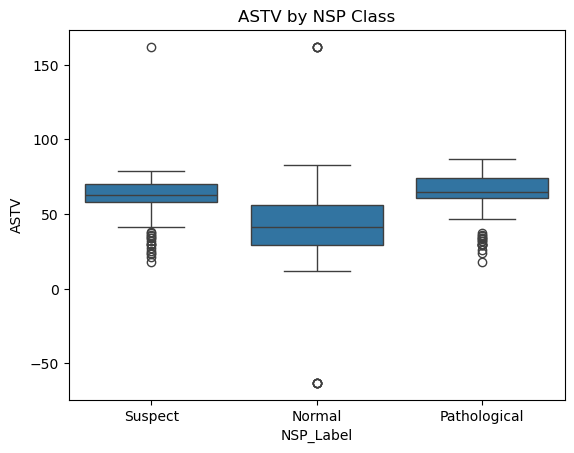

In [7]:
#Boxplot LB by NSP
sns.boxplot(data=df, x='NSP_Label', y='LB')
plt.title("Baseline FHR by NSP Class")
plt.show()

#Boxplot ASTV by NSP
sns.boxplot(data=df, x='NSP_Label', y='ASTV')
plt.title("ASTV by NSP Class")
plt.show()

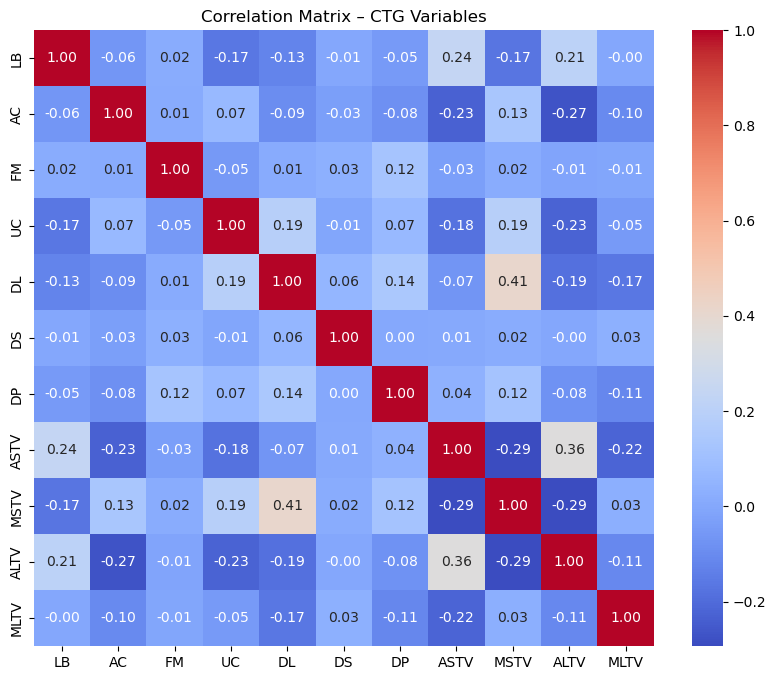

In [8]:
#Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix – CTG Variables")
plt.show()

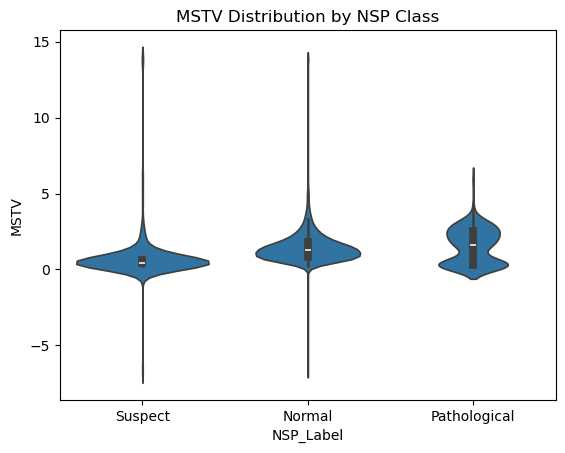

In [9]:
#Violin plot MSTV by class
sns.violinplot(data=df, x='NSP_Label', y='MSTV')
plt.title("MSTV Distribution by NSP Class")
plt.show()

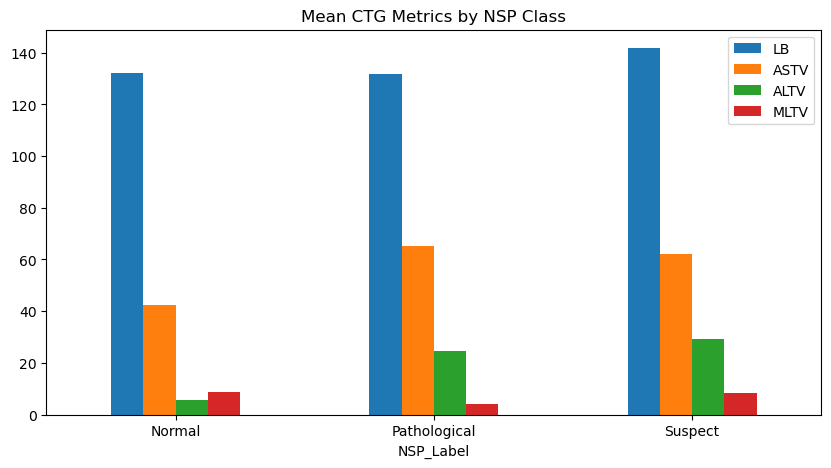

In [10]:
#Bar chart of mean values
group_means = df.groupby('NSP_Label')[['LB','ASTV','ALTV','MLTV']].mean()
group_means.plot(kind='bar', figsize=(10,5))
plt.title("Mean CTG Metrics by NSP Class")
plt.xticks(rotation=0)
plt.show()

In [11]:
#Task4 Top correlations with NSP
corr_with_nsp = df[numeric_cols + ['NSP']].corr()['NSP'].drop('NSP').sort_values()
print(corr_with_nsp)

AC     -0.313577
UC     -0.185294
MLTV   -0.113516
MSTV   -0.095895
DL      0.024736
DS      0.065301
FM      0.074670
LB      0.131794
DP      0.294384
ALTV    0.366485
ASTV    0.420983
Name: NSP, dtype: float64


Task5

Conclusion
Key Insights Summary
After doing the full exploratory data analysis on the Cardiotocographic dataset, here are the main things we found:

1. Dataset Overview-

The dataset has 2,126 patient records with 14 features related to fetal heart rate monitoring.

The target column is NSP (Fetal State Class):

1 = Normal (~78% of data)

2 = Suspect (~14% of data)

3 = Pathological (~8% of data)

The dataset is imbalanced — most babies are healthy.

2. Missing Values-

We found 167 missing values in columns like LB, AC, MLTV, Width, Tendency, and NSP.

We filled them using the mean of each column, which is the safest basic approach.

3. Most Important Features-

ASTV (Abnormal Short Term Variability) — highest in Pathological cases. Very important feature.

MSTV (Mean Short Term Variability) — very low values appear in Pathological babies. This is a danger sign.

ALTV (Abnormal Long Term Variability) — also elevated in Pathological cases.

AC (Accelerations) — Normal babies have more accelerations, which means they are healthy.

LB (Baseline FHR) — stays around 133 bpm for all classes, so alone it is not very useful.

4. Patterns Found-

Babies with low MSTV + high ASTV are likely in the Pathological or Suspect group.

Most features like FM, DS, DP are near zero for most patients — they are rare events.

A few strong correlations exist between variability features (ASTV ↔ ALTV).

How These Findings Impact Decision-Making
Doctors can use ASTV and MSTV values as early warning signals for fetal distress.

Hospitals can build an automated alert system — if ASTV is very high and MSTV is very low, flag the case for immediate review.

The class imbalance (78% Normal) means if we build an ML model later, we need to be careful — a model that always predicts "Normal" would still be 78% accurate but useless.